1.	Perform linear regression algorithm to predict

a.	The price of a used car. 	Dataset: Used_Car_dataset.csv

b.	The price of a House.  	Dataset: Housing_price_dataset.csv

c.	CO2 Emission	 		Dataset: FuelConsumption_dataset.csv

Consider both univariate and multivariate cases for these problems. Elaborate gradient descent algorithm and hyper-parameter tuning for the best result with predefined convergent criteria. Display the hypothesis function and find the accuracy of the linear regression in predicting the correct price.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [ ]:
df = pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


# Univariate Linear Regression (Using ENGINESIZE)

In [ ]:
X = df[['ENGINESIZE']].values
y = df[['CO2EMISSIONS']].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
mean_X = np.mean(X_train)
std_X = np.std(X_train)
X_train_scaled = (X_train - mean_X) / std_X
X_test_scaled = (X_test - mean_X) / std_X

In [ ]:
alpha = 0.01
iterations = 1000
m = len(y_train)
theta_0 = 0
theta_1 = 0
cost_history = []

In [ ]:
for i in range(iterations):
    y_pred = theta_0 + theta_1 * X_train_scaled
    error = y_pred - y_train
    cost = (1/(2*m)) * np.sum(error**2)
    cost_history.append(cost)

    d_theta0 = (1/m) * np.sum(error)
    d_theta1 = (1/m) * np.sum(error * X_train_scaled)

    theta_0 -= alpha * d_theta0
    theta_1 -= alpha * d_theta1

In [ ]:
print(f"Hypothesis Function: h(x) = {theta_0:.2f} + {theta_1:.2f} * x")

Hypothesis Function: h(x) = 257.25 + 55.13 * x


In [ ]:
y_test_pred = theta_0 + theta_1 * X_test_scaled

In [ ]:
y_test_pred = theta_0 + theta_1 * X_test_scaled
r2 = r2_score(y_test, y_test_pred)
print(f"R² Score (Univariate): {r2:.4f}")

R² Score (Univariate): 0.7616


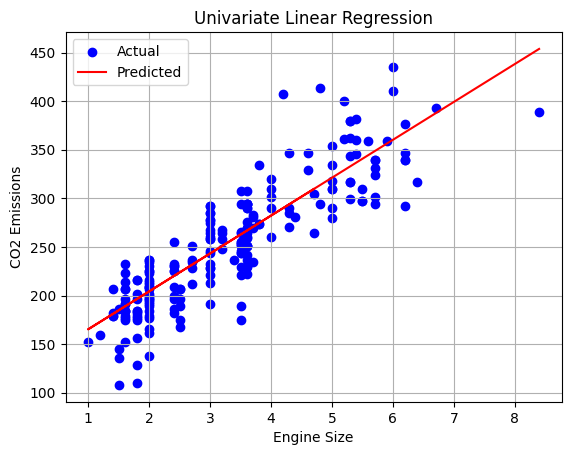

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_test_pred, color='red', label='Predicted')
plt.xlabel('Engine Size')
plt.ylabel('CO2 Emissions')
plt.title('Univariate Linear Regression')
plt.legend()
plt.grid(True)
plt.show()

# Multivariate Linear Regression

In [ ]:
features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB']
X = df[features].values
y = df[['CO2EMISSIONS']].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
mean_X = np.mean(X_train, axis=0)
std_X = np.std(X_train, axis=0)
X_train_scaled = (X_train - mean_X) / std_X
X_test_scaled = (X_test - mean_X) / std_X

In [ ]:
m, n = X_train_scaled.shape
theta = np.zeros((n + 1, 1))  # Including theta_0
X_b = np.c_[np.ones((m, 1)), X_train_scaled]  # add x0 = 1 for bias term
iterations = 1000
alpha = 0.01
cost_history = []

In [ ]:
for i in range(iterations):
    y_pred = X_b.dot(theta)
    error = y_pred - y_train
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    cost_history.append(cost)

    gradients = (1 / m) * X_b.T.dot(error)
    theta -= alpha * gradients

In [ ]:
print("Hypothesis Function:")
for i, f in enumerate(['1'] + features):
    print(f" + ({theta[i][0]:.4f} * {f})")

Hypothesis Function:
 + (257.2456 * 1)
 + (15.0298 * ENGINESIZE)
 + (13.9731 * CYLINDERS)
 + (12.3278 * FUELCONSUMPTION_CITY)
 + (9.3733 * FUELCONSUMPTION_HWY)
 + (11.4068 * FUELCONSUMPTION_COMB)


In [ ]:
X_test_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]
y_pred_test = X_test_b.dot(theta)
r2 = r2_score(y_test, y_pred_test)
print(f"R² Score (Multivariate): {r2:.4f}")

R² Score (Multivariate): 0.8756


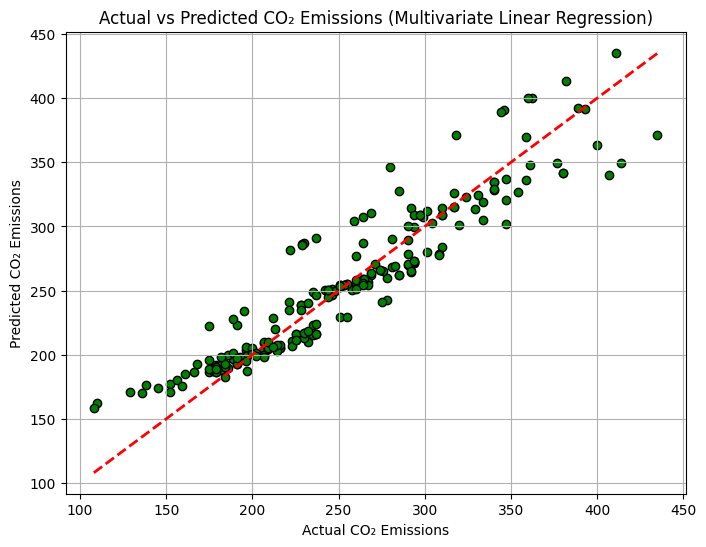

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color='green', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual CO₂ Emissions")
plt.ylabel("Predicted CO₂ Emissions")
plt.title("Actual vs Predicted CO₂ Emissions (Multivariate Linear Regression)")
plt.grid(True)
plt.show()